# Compact
Load Compact CSV files and create a DataFrame named `df`.

In [26]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Compact"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
df_clean = df.copy()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
df.head()

Loaded 2045 rows from 214 file(s) in /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/Compact


,Date,Title,Inhalt,URL,source,source_file
0,2025-06-11,COMPACT gegen Regierung: So war der 2. Tag!,Der zweite und letzte Verhandlungstag im COMPACT-Verbotsverfahren ist abgeschlossen. Das Urteil wird am 24.06. bekannt gegeben. Wie verlief es heute vor Gericht? Wessen Chancen stehen am Ende besser? Kann sich die Regierung durchsetzen oder obsiegt die Pressefreiheit? Eine Analyse und die Prognose zu diesem historischen Verfahren liefern Ihnen das Ehepaar Elsässer und Paul Klemm.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,https://www.compact-online.de/compact-gegen-regierung-so-war-der-2-tag/,Compact,Compact_2025-06-11_raw.csv
1,2025-06-11,COMPACT-Verbot 2024: Der Film,"Als Nancy Faeser eskalierte. Die denkwürdigsten Szenen des 16. Juli 2024, also plötzlich die Formate von COMPACT verboten wurden.\n\nUnser Cutter hat anlässlich des laufenden Verbotsverfahren die bemerkenswertesten Szenen zusammengeschnitten.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/compact-verbot-2024-der-film/,Compact,Compact_2025-06-11_raw.csv
2,2025-06-11,Drogen und Rituale: Mysteriöse Inka-Stätte entdeckt,"Ein neuer Fund in den peruanischen Anden eröffnet einen neuen Blick auf die Kultur der Inka: Sie waren nicht nur große Baumeister, sondern erforschten auch astronomische und spirituelle Geheimnisse – unter Einsatz psychoaktiver Substanzen. Mehr über die Frühzeit der Menschheit und historische Ungereimtheiten lesen Sie „Geheime Geschichte – Von den Pharaonen bis zur Kabale im Vatikan“ – unserer neuen Geschichtsausgabe. Hier mehr erfahren. \n\nHoch oben in den schroffen Felsen der peruanischen Anden, auf fast 3.000 Metern Höhe, haben Archäologen eine Entdeckung gemacht, die nicht nur die Fachwelt elektrisiert: Ein geheimer, unterirdischer Raum, der vermutlich seit Jahrtausenden unberührt war, gibt nun Einblicke in die mysteriösen Rituale der Inka – jenes alten lateinamerikanischen Volkes, das um die Hauptstadt Cusco im heutigen Peru lebte und ab 1438 viele Gebiete eroberte, insbesondere im Anden-Gebirge. Das Reich der Inka gilt als das größte seiner Zeit und umfasste schätzungsweise ...",https://www.compact-online.de/drogen-und-rituale-mysterioese-inka-staette-entdeckt/,Compact,Compact_2025-06-11_raw.csv
3,2025-06-11,Trumps Einsatz in Los Angeles: Ein Medientrauma,"Das Durchgreifen des US-Präsidenten gegen das Treiben illegaler Einwanderer in Los Angeles treibt etablierte Medien um. Wir zeigen auf, wie Trump tickt und was wir von ihm noch zu erwarten haben. Sichern Sie sich am besten gleich unsere Sonderausgabe „Trump. Sein Leben. Seine Politik. Sein großes Comeback.“ Hier mehr erfahren.\n\nDie Straßen von Los Angeles stehen in Flammen – brennende Polizeiwagen, fliegende Steine und Proteste. Die Szenen lassen an einen Bürgerkrieg denken. Auslöser der Krawalle waren Razzien der Einwanderungsbehörden gegen illegale Migranten. Präsident Donald Trump reagiert entschlossen und schickt 2.000 Soldaten der Nationalgarde sowie 700 Marines, um die Gewalt in den Griff zu bekommen – ein Schritt, der weltweit für Schlagzeilen sorgt. Die internationale Presse ist in Aufruhr, die Meinungen aus der Straße sind gespalten.\n\nTrumps Entscheidung, Kaliforniens Gouverneur Gavin Newsom und die Bürgermeisterin von Los Angeles, Karen Bass, beide Demokraten, zu über...",https://www.compact-online.de/trumps-einsatz-in-los-angeles-ein-medientrauma/,Compact,Compact_2025-06-11_raw.csv
4,2025-06-11,Verrat an BismarckCOMPACT+,"Essay von Rolf Hochhut. Deutschland hat seinen großen Kanzler vergessen – vor allem von seiner klugen Ausgleichspolitik mit Russland wollen die heutigen NATO-Vasallen nichts mehr wissen. _ von Rolf Hochhuth Bismarcks geheimer Rückversicherungsvertrag mit Russland sah vor: Berlin und Petersburg bleiben «wohlwollend neutral», wird eines der beiden Länder «in Krieg mit einer Großmacht verwicke

In [27]:
# compute and display missing values per column for the cleaned dataframe
missing = df_clean.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df_clean)) * 100
missing = missing.sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
Date,0,0.0
Title,0,0.0
Inhalt,0,0.0
URL,0,0.0
source,0,0.0
source_file,0,0.0


In [28]:
# filter timeframe Aug 2025 through Jan 2026 (inclusive)
start, end = "2025-08-01", "2026-01-31"
dates = pd.to_datetime(df_clean["Date"], errors="coerce")
mask = (dates >= start) & (dates <= end)

df_aug2025_jan2026 = df_clean.loc[mask].copy()
df_aug2025_jan2026["Date"] = pd.to_datetime(df_aug2025_jan2026["Date"])
df_clean = df_aug2025_jan2026.copy()

print(f"Rows in selected period: {len(df_clean)}")
df_clean.sort_values("Date").head()

Rows in selected period: 1614


,Date,Title,Inhalt,URL,source,source_file
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/,Compact,Compact_2025-08-01_raw.csv
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/,Compact,Compact_2025-08-01_raw.csv
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/,Compact,Compact_2025-08-01_raw.csv
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gersdorf,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/,Compact,Compact_2025-08-01_raw.csv
348,2025-08-01

In [29]:
# keep only the requested columns
_keep = ["Date", "Title", "Inhalt", "URL"]

if 'df_clean' in globals():
    df_clean = df_clean.loc[:, _keep].copy()

if 'df_aug2025_jan2026' in globals():
    df_aug2025_jan2026 = df_aug2025_jan2026.loc[:, _keep].copy()

if 'df' in globals():
    df = df.loc[:, _keep].copy()

# show result
df_clean.head()

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gersdorf,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: Tausende Dokumente bleiben unter Verschluss, eine Klientenliste gibt es angeblich gar nich

In [30]:
from IPython.display import display
display(df_clean.head(3))

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/


Removal of "Mehr zum Thema"

In [31]:
import re
def remove_mehr_zum_thema(text):
    if pd.isna(text):
        return text
    
    # Remove everything from "Mehr zum Thema" until end
    cleaned = re.sub(r"\n*\s*Mehr zum Thema.*$", "", text, flags=re.DOTALL)
    return cleaned.strip()

df_clean["Inhalt"] = df_clean["Inhalt"].apply(remove_mehr_zum_thema)

In [32]:
df_clean.head()

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gersdorf,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: Tausende Dokumente bleiben unter Verschluss, eine Klientenliste gibt es angeblich gar nich

In [33]:
!pip install seaborn

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy() if "df_clean" in globals() else df.copy()
eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")

text_col = "Inhalt"
eda_df[text_col] = eda_df[text_col].astype("string")
eda_df = eda_df.dropna(subset=["Date", text_col]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 1,614


In [35]:
eda_df["article_length_words"] = eda_df[text_col].str.split().str.len()
eda_df["article_length_chars"] = eda_df[text_col].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count    1614.0
mean      495.9
std       481.7
min        23.0
10%        70.0
25%       118.0
50%       419.0
75%       670.2
90%      1118.2
95%      1479.7
99%      2201.0
max      4324.0
Name: article_length_words, dtype: float64

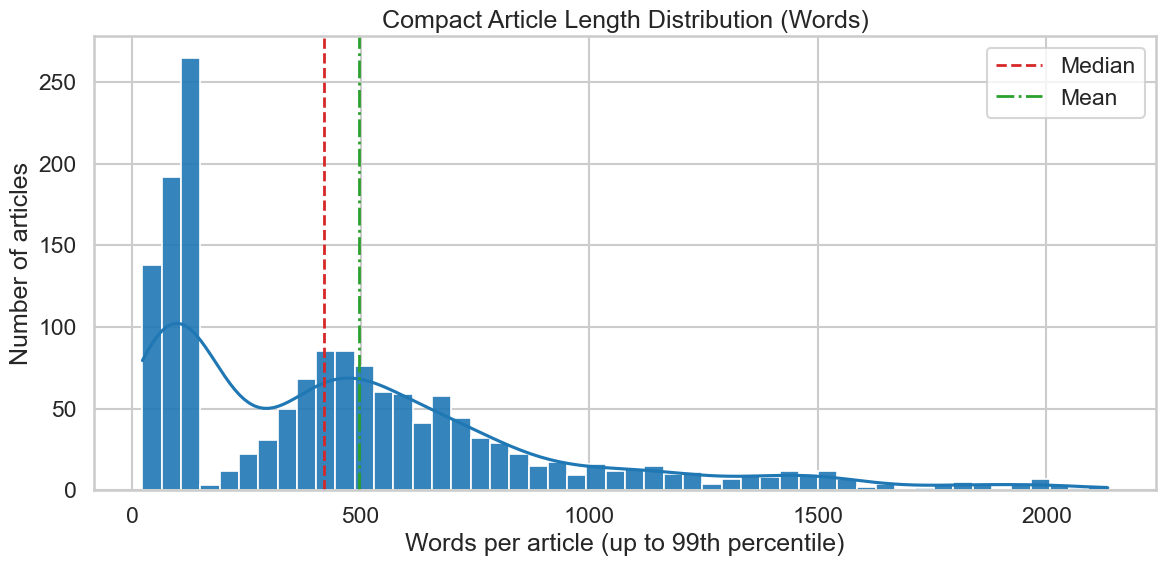

In [36]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Compact Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
# Inspect 20 shortest articles by word count
df_inspect = eda_df if "eda_df" in globals() else df_clean.copy()

if "article_length_words" not in df_inspect.columns:
    df_inspect["article_length_words"] = df_inspect["Inhalt"].astype("string").str.split().str.len()

# ensure source column exists (most data is from SOURCE_NAME == "Compact")
if "source" not in df_inspect.columns:
    df_inspect["source"] = SOURCE_NAME if "SOURCE_NAME" in globals() else "Compact"

# build result (Title, text, source, word_count) sorted ascending
shortest = (
    df_inspect.sort_values("article_length_words", ascending=True)
    .loc[:, ["Title", "Inhalt", "source", "article_length_words"]]
    .head(20)
    .rename(columns={"Inhalt": "text", "article_length_words": "word_count"})
)

# allow longer text columns to be displayed
pd.options.display.max_colwidth = 1000

display(shortest)

,Title,text,source,word_count
632,Macron am Boden: Live beim Aufstand!,Frankreich im Ausnahmezustand – COMPACT ist live vor Ort dabei!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,23
594,Albaner (18) sticht auf Lehrerin ein! NOT-OP!,Amoklauf in Essener Schule. SEK muss schießen. Dr. Stephanie Elsässer klärt auf!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,25
646,MOSSAD und 9/11,Heute vor 24 Jahren: Israelische Geheimdienstler wurden nach den Anschlägen des 11. September 2001 vom FBI festgenommen und zwei Monate eingesperrt. Waren sie in das Terrorkomplott verwickelt?,Compact,27
464,„Remigration!“: Söder-Interview wird abgebrochen!,Aufregung am Bundestag! Das Sommer-Interview der ARD mit CSU-Chef Söder muss abgebrochen werden.\n\nWir sind vor Ort!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,30
1187,Halle (Saale): Antifa brüllt gegen Buchmesse,"Wirbel um die «Seitenwechsel»-Buchmesse in Halle (Saale).\n\nSehen Sie hier brüllende Antifas, spannende Interviews und Impressionen von unserem Messestand!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Compact,32
1901,Vor Ort: Orban geht gegen Hammerbande vor!,"In Budapest strebt der Prozess gegen Hammerbanden-„Maja“ seinem Höhepunkt entgegen. Unser Korrespondent Sebastian Schmidtke ist dabei und dokumentiert, wie deutsche Politiker vor Ort Stimmung machen.\n\nDie Reportage sehen Sie in dem Video oben.",Compact,33
1388,AfD-Jugend: COMPACT beim Kampf um Gießen!,"Ausnahmezustand in Gießen: Tausende Antifa wollen den Gründungskongress der AfD-Jugend stürmen! Blockaden, Wasserwerfer, Angriffe auf Polizisten und Teilnehmer. COMPACT mittendrin!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Compact,33
1575,Gefahr Migration: Ex-Islamist packt aus!,Irfan Peci war Propaganda-Chef der deutschen al-Qaida! Inzwischen hat er zum christlichen Glauben gefunden und warnt vor den schrecklichen Folgen der Massenmigration. Was steht Deutschland bevor?\n\nUnsere heutige Shop-Empfehlung: „COMPACT-Spezial 45: Mädchen. Messer. Morde“,Compact,34
1656,Rückblick: Unsere größten TV-Highlights!,Nur noch wenige Stunden… – 2025 war ein spektakuläres Jahr mit vielen Höhen und Tiefen. In unserem COMPACT-Rückblick sehen Sie die wichtigsten Ereignisse in einer kurzweiligen Zusammenfassung. Wir wünschen einen frohen Jahreswechsel und ein gesundes Neues!,Compact,36
1692,Spreewald: Wird SIE die erste AfD-Landrätin?,Widerstand im Gurkenland: Der Kreis Oberspreewald-Lausitz gilt als AfD-Hochburg. In wenigen Tagen wird hier ein neuer Landrat gewählt. Die blaue Kandidatin hat gute Chancen. Paul Klemm hat sie mit der Kamera begleitet.\n\nUnsere heutige Produktempfehlung: Silbermedaille Höcke-Taler,Compact,37


--> This indicates two types of documents in the corpus: News briefs / ticker posts and Normal articles

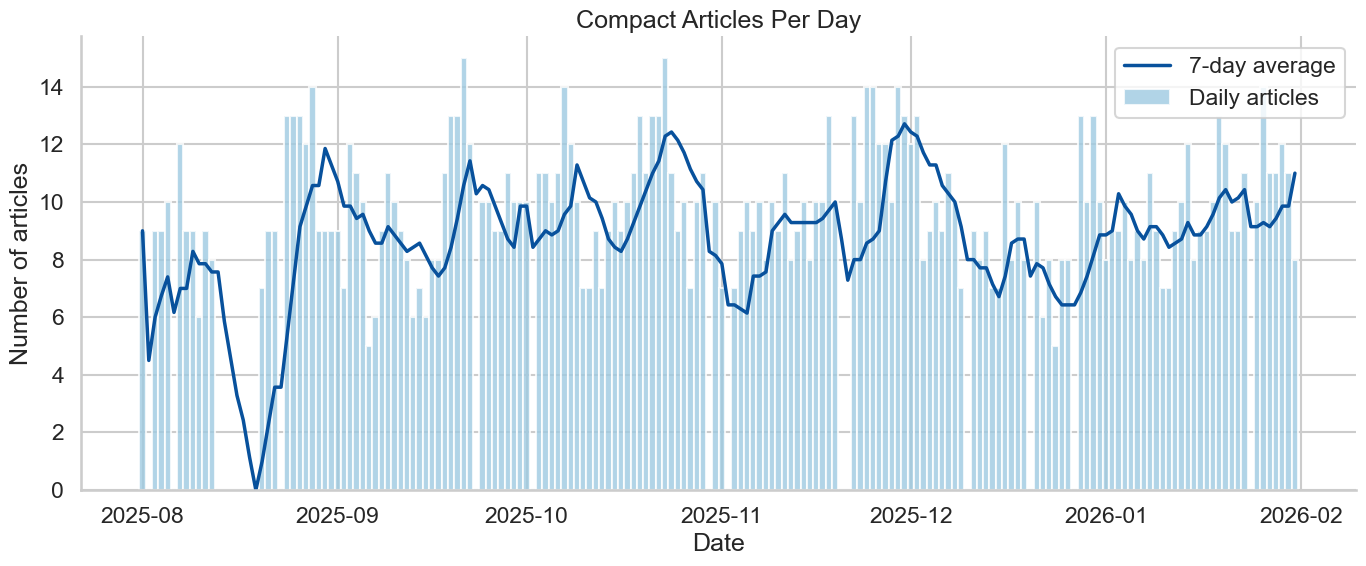

In [38]:
daily_counts = (
    eda_df.set_index("Date")
    .resample("D")
    .size()
    .rename("articles")
    .reset_index()
)
daily_counts["rolling_7d"] = daily_counts["articles"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    daily_counts["Date"],
    daily_counts["articles"],
    color="#9ecae1",
    alpha=0.8,
    width=1.0,
    label="Daily articles",
)
ax.plot(
    daily_counts["Date"],
    daily_counts["rolling_7d"],
    color="#08519c",
    linewidth=2.5,
    label="7-day average",
)

ax.set_title("Compact Articles Per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## BERTopic

In [39]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "1a_BERTopic").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 1a_BERTopic")

project_root = resolve_project_root()
module_root = project_root / "1a_BERTopic"

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

In [40]:
from bertopic_config import BERTopicConfig, title_config
from bertopic_pipeline import run_bertopic_pipeline


In [41]:
df_clean[["Inhalt", "Title", "URL"]].head()


,Inhalt,Title,URL
344,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Blond! Linker Hass gegen Jeans-Model,https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",Die Macht der Israel-Lobby in den USA,https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",Ein Polizist aus dem Volk,https://www.compact-online.de/ein-polizist-aus-dem-volk/
347,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",SPD-Politiker fordert Rückzug von Brosius-Gersdorf,https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/
348,"Epstein, Epstein, alles muss versteckt sein: Tausende Dokumente bleiben unter Verschluss, eine Klientenliste gibt es angeblich gar nicht. Trumps Kehrtwende wirft Fragen auf – und bringt die Gerüchteküche zum Brodeln. 

In [42]:
# 1) BERTopic on full article text
# Compact historically used a looser HDBSCAN setup than the global defaults.
# Keep that here so the outlet does not collapse into only a few broad clusters.
config_full_text = BERTopicConfig(
    hdbscan_min_cluster_size=10,
    hdbscan_min_samples=8,
)

result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Inhalt",
    config=config_full_text,
    id_col="URL",
    source_name="Compact",
)

# 2) BERTopic on titles only
result_title = run_bertopic_pipeline(
    df=df_clean,
    text_col="Title",
    config=title_config(),
    id_col="URL",
    source_name="Compact",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-19 16:28:49,628 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/50 [00:00<?, ?it/s]

2026-03-19 16:28:56,611 - BERTopic - Embedding - Completed ✓
2026-03-19 16:28:56,612 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-19 16:28:59,101 - BERTopic - Dimensionality - Completed ✓
2026-03-19 16:28:59,101 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-19 16:28:59,125 - BERTopic - Cluster - Completed ✓
2026-03-19 16:28:59,127 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-19 16:28:59,662 - BERTopic - Representation - Completed ✓


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-19 16:29:04,591 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/50 [00:00<?, ?it/s]

2026-03-19 16:29:05,646 - BERTopic - Embedding - Completed ✓
2026-03-19 16:29:05,646 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-19 16:29:08,243 - BERTopic - Dimensionality - Completed ✓
2026-03-19 16:29:08,244 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-19 16:29:08,266 - BERTopic - Cluster - Completed ✓
2026-03-19 16:29:08,269 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-19 16:29:08,286 - BERTopic - Representation - Completed ✓


In [43]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,469,-1_afd_passwort_merz_vergessen,"[afd, passwort, merz, vergessen, us, habe, antifa, buch, ihn, sei]","[Intrigen in exotischen Palästen, Verfolgungsjagden durch Bazare, blitzende Degen in glühender Sonne, palmengesäumte Straßen mit berittenen Elefanten, die skurrilen Witze des Komikers Theo Lingen – alles, was den Tiger von Eschnapur (1938) dem Publikum an Schauwerten bietet, ist mit einem Schlag vergessen: In dem Moment, wenn La Jana ihren Tanz beginnt. Schlangenartig ihre Bewegung, die Haut glitzernd, der Blick hypnotisch – die mythische Repräsentantin eines Indiens, wie es nur im Filmstudio entstehen kann. Die großzügigen Palastbauten Dieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten. Bitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop Anmelden Benutzername oder E-Mail-Adresse Passwort Angemeldet bleiben Passwort vergessen? Klicke hier, um es zurückzusetzen., Interview mit Parteienforscher Klecha. Pädophile Positionen waren in den 1980er Jahren bei den Grünen hoffähig. Wir sprachen dazu mit e..."
1,0,173,0_afd_partei_cdu_spd,"[afd, partei, cdu, spd, weidel, alice, alice weidel, höcke, bsw, blauen]","[Der Höhenflug der AfD hält an. Jetzt ist es eine Meinungsumfrage für Rheinland-Pfalz, die für Aufsehen sorgt. Die Blauen überholen die SPD! Handeln Sie weitsichtig und sichern Sie sich jetzt unsere Kanzlermedaille Alice Weidel in Silber; gibt es nur bei COMPACT. Hier mehr erfahren. Die politische Landschaft in Rheinland-Pfalz steht vor einem Umbruch. Etablierte Parteien erkennen die Zeichen der Zeit einfach nicht. Der Wendepunkt Eine aktuelle Umfrage des Meinungsforschungsinstituts Insa zeigt auf: Die AfD legt kräftig zu und erreicht mit 23 Prozent erstmals mehr Zustimmung als die SPD, die auf 22 Prozent kommt. Dies ist ein bemerkenswerter Wendepunkt, denn die Sozialdemokraten blicken in Rheinland-Pfalz auf eine lange Erfolgsgeschichte zurück. Dass die AfD die SPD in diesem traditionsreichen SPD-Bundesland überholt, unterstreicht die wachsende Unzufriedenheit vieler Wähler mit den Altparteien. Die CDU bleibt zwar mit 27 Prozent stärkste Kraft, verliert jedoch an Boden, während der..."
2,1,162,1_messer_mädchen_morde_mädchen messer,"[messer, mädchen, morde, mädchen messer, messer morde, polizei, täter, opfer, spezial, jährige]","[Seit dem Unglücksjahr 2015 wurden fast 500.000 Deutsche Opfer von Migrantengewalt. Hinter dieser unfassbaren Zahl verbergen sich erschütternde Schicksale. Wir geben den Gequälten, Geschändeten und Gemesserten ein Gesicht und eine Stimme – und zeichnen in unserer brandneuen Spezial-Ausgabe «Mädchen, Messer, Morde – Die Opfer der offenen Grenzen von Merkel bis Merz» die Blutspur nach. Eine Chronik des Grauens! Hier mehr erfahren. Eine parlamentarische Anfrage der AfD-Fraktion im Bundestag förderte unlängst das wahre Ausmaß der Schande zutage: Laut Antwort der Merz-Regierung wurden seit Merkels fataler Grenzöffnung 2015 insgesamt 460.000 Deutsche Opfer von Straftaten durch Migranten! 135.668 Mal waren Syrer die Täter, 82.960 Mal Afghanen. Diese Zahlen machen einen fassungslos und wütend, doch sie bestätigen im Grunde nur das, was man längst wusste. Erschütternde Taten, ergreifende Schicksale Hinter den nackten Zahlen verbergen sich schlimme Schicksale: Vergewaltigte Frauen, erstochen..."
3,2,153,2_russland_ukraine_putin_krieg,"[russland, ukraine, putin, krieg, gegen russland, trump, nato, russische, eu, russischen]","[Schon innerhalb der nächsten zwei Wochen soll es erneut zu einem Treffen zwischen Donald Trump und Wladimir Putin in Ungarns Hauptstadt kommen. Die deutsche und internationale Presse reagiert größtenteils negativ, während der Ökonom Markus Krall vor einem möglichen Anschlag auf Putin warnt. In der COMPACT-Edition „Wladimir Putin: Geschichte Russlands“ lesen Sie den russischen Präsidenten im O-Ton. Hier mehr erfahren. US-Präsident Donald Trump, sei

In [44]:
doc_info = result["doc_info"]
doc_info.head()

,original_index,document_id,source_name,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,344,https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/,Compact,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie! Dr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert. COMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",4,4_ruhs_julia ruhs_julia_passwort,"[ruhs, julia ruhs, julia, passwort, ihrem, frau, grüne, links grüne, rechts, links]","[Die Stadtbild-Debatte ist auch ein Prüfstein für die Meinungsfreiheit in unserem Land. Mainstream-Medien stehen zwischen Merz und Empörung am Rande des Geschehens und haben Angst vor einem „falschen Zungenschlag“. Die Journalistin Julia Ruhs aber traut sich nach vorn. Wieder einmal. Wer ihr Buch „Links-grüne Medienmacht“ gelesen hat, der weiß, wie mutig sie sein muss. Großartige Einblicke! Hier mehr erfahren. Wir erinnern uns: Julia Ruhs stand für das ARD-Format Klar, das den Versuch unternahm, abweichende Meinungen zumindest am Rande auch zu berücksichtigen. Das war den Moralwächtern im Öffentlich-Rechtlichen bereits zu viel. Die Moderatorin wurde eiskalt abserviert und aussortiert. In ihrem Buch rechnet sie mit der linken GEZ-Blase gründlich ab. Ruhs mit klaren Worten Jetzt hat sich Julia Ruhs wieder zu Wort gemeldet. Im Focus hatte sie Gelegenheit, zur aktuellen Stadtbild-Debatte im Rahmen eines eigenen Beitrags Stellung zu beziehen. Und sie enttäuschte nicht, sondern fand glas...",ruhs - julia ruhs - julia - passwort - ihrem - frau - grüne - links grüne - rechts - links,0.900184,False
1,345,https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/,Compact,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen. Diese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen. Das Buch von Mearsheimer/Wal...",-1,-1_afd_passwort_merz_vergessen,"[afd, passwort, merz, vergessen, us, habe, antifa, buch, ihn, sei]","[Intrigen in exotischen Palästen, Verfolgungsjagden durch Bazare, blitzende Degen in glühender Sonne, palmengesäumte Straßen mit berittenen Elefanten, die skurrilen Witze des Komikers Theo Lingen – alles, was den Tiger von Eschnapur (1938) dem Publikum an Schauwerten bietet, ist mit einem Schlag vergessen: In dem Moment, wenn La Jana ihren Tanz beginnt. Schlangenartig ihre Bewegung, die Haut glitzernd, der Blick hypnotisch – die mythische Repräsentantin eines Indiens, wie es nur im Filmstudio entstehen kann. Die großzügigen Palastbauten Dieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten. Bitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop Anmelden Benutzername oder E-Mail-Adresse Passwort Angemeldet bleiben Passwort vergessen? Klicke hier, um es zurückzusetzen., Interview mit Parteienforscher Klecha. Pädophile Position

In [45]:
compact_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)

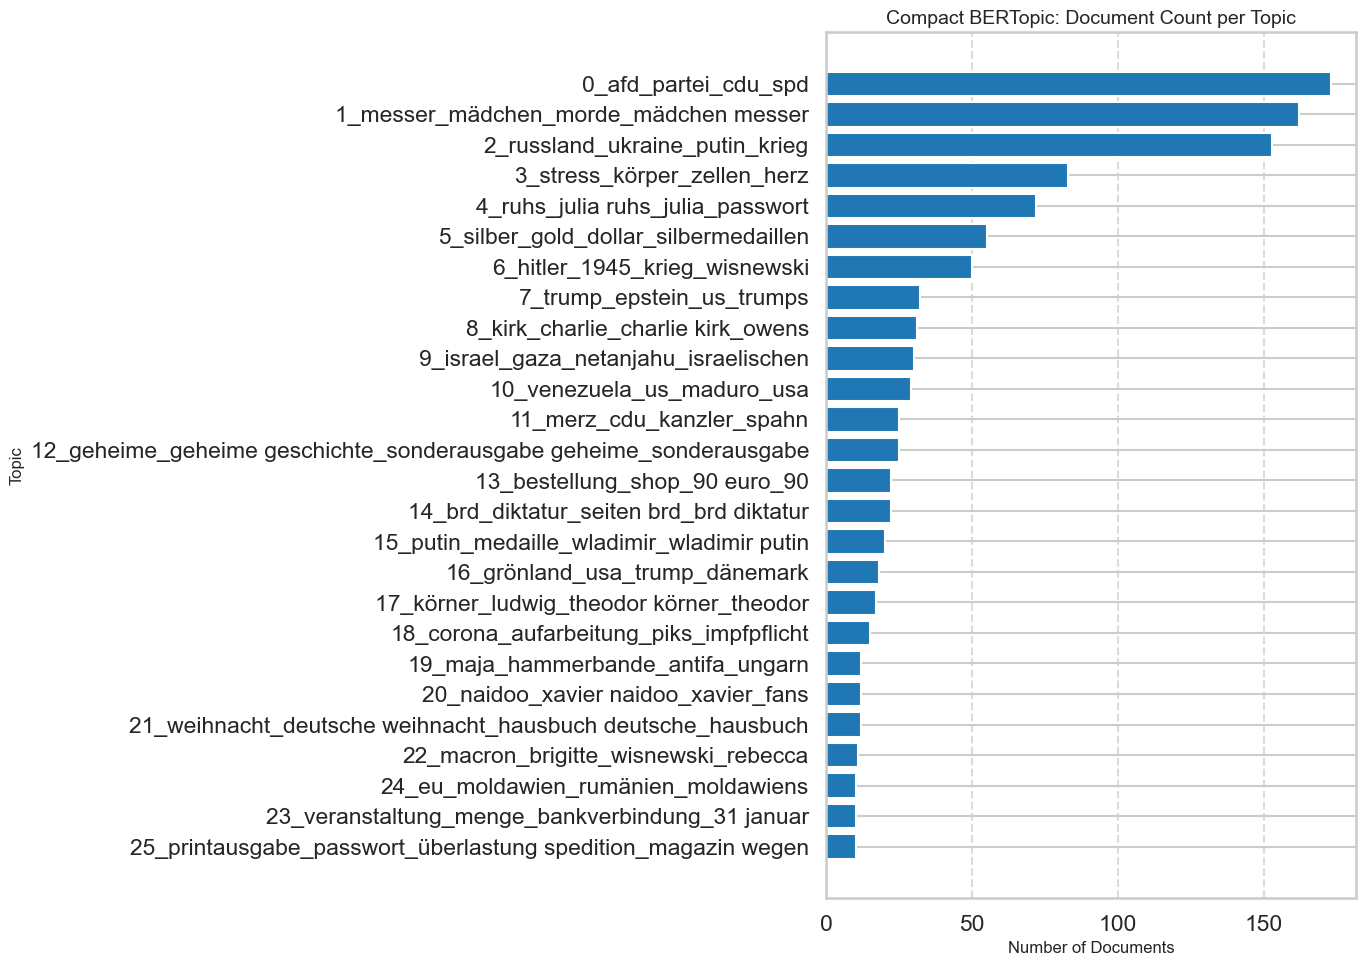

In [46]:
fig, ax = plt.subplots(figsize=(14, 10))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info['Topic'] != -1].copy()
topic_counts = topic_counts.sort_values('Count', ascending=True)

ax.barh(topic_counts['Name'], topic_counts['Count'], color='#1f77b4', edgecolor='white')

ax.set_xlabel('Number of Documents', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
ax.set_title('Compact BERTopic: Document Count per Topic', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

6it [00:01,  3.97it/s]


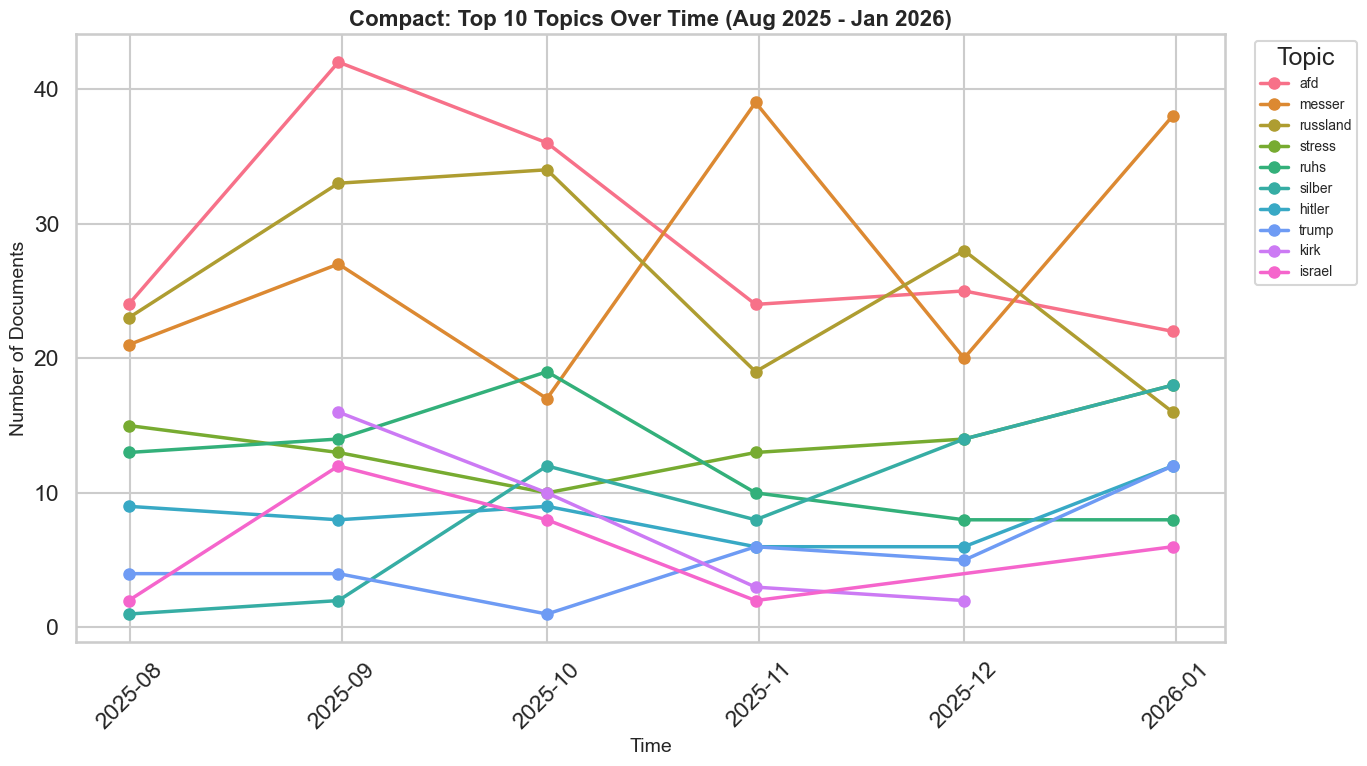

In [47]:
# Prepare data for topics over time
prepared_dates = pd.to_datetime(result["prepared_documents"]["Date"], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()
docs_for_time = [doc for doc, ok in zip(result["docs"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    nr_bins=6
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info['Topic'] != -1].nlargest(10, 'Count')['Topic'].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time['Topic'].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered['Topic'] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split('_')[1] if '_' in label else label
    ax.plot(topic_data['Timestamp'], topic_data['Frequency'], 
            marker='o', linewidth=2.5, markersize=8, 
            color=palette[i], label=short_label)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Number of Documents', fontsize=14)
ax.set_title('Compact: Top 10 Topics Over Time (Aug 2025 - Jan 2026)', fontsize=16, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
# Final BERTopic comparison table: all topics + representative words
from IPython.display import display

topics_comparison_df = topic_info[["Topic", "Name", "Count"]].copy()

def _representative_words_for_topic(topic_id: int) -> str:
    terms = result["topic_model"].get_topic(int(topic_id)) or []
    return ", ".join(word for word, _ in terms)

topics_comparison_df["Representative_Words"] = topics_comparison_df["Topic"].apply(_representative_words_for_topic)
topics_comparison_df = topics_comparison_df.sort_values("Topic").reset_index(drop=True)

with pd.option_context("display.max_colwidth", None, "display.width", 220):
    display(topics_comparison_df)


,Topic,Name,Count,Representative_Words
0,-1,-1_afd_passwort_merz_vergessen,469,"afd, passwort, merz, vergessen, us, habe, antifa, buch, ihn, sei"
1,0,0_afd_partei_cdu_spd,173,"afd, partei, cdu, spd, weidel, alice, alice weidel, höcke, bsw, blauen"
2,1,1_messer_mädchen_morde_mädchen messer,162,"messer, mädchen, morde, mädchen messer, messer morde, polizei, täter, opfer, spezial, jährige"
3,2,2_russland_ukraine_putin_krieg,153,"russland, ukraine, putin, krieg, gegen russland, trump, nato, russische, eu, russischen"
4,3,3_stress_körper_zellen_herz,83,"stress, körper, zellen, herz, gehirn, ernährung, oft, studien, mangel, insbesondere"
5,4,4_ruhs_julia ruhs_julia_passwort,72,"ruhs, julia ruhs, julia, passwort, ihrem, frau, grüne, links grüne, rechts, links"
6,5,5_silber_gold_dollar_silbermedaillen,55,"silber, gold, dollar, silbermedaillen, preis, us, medaillen, edelmetalle, geld, silberpreis"
7,6,6_hitler_1945_krieg_wisnewski,50,"hitler, 1945, krieg, wisnewski, 1939, alois, gegen deutschland, reich, sowjetunion, berlin"
8,7,7_trump_epstein_us_trumps,32,"trump, epstein, us, trumps, epsteins, donald, präsidenten, akten, donald trump, präsident"
9,8,8_kirk_charlie_charlie kirk_owens,31,"kirk, charlie, charlie kirk, owens, trump, mord, kirks, tiefen, carlson, usa"


In [49]:
print("Experimental BERTopic v2 run removed. The saved final Compact model uses the standard BERTopic pipeline above.")


Experimental BERTopic v2 run removed. The saved final Compact model uses the standard BERTopic pipeline above.


In [50]:
from pathlib import Path
import shutil
import pandas as pd
from copy import deepcopy

# Keep aligned with the exact reduced-model baseline selected above (result_full_text).
base_result = result_full_text
topic_model_base = base_result["topic_model"]
docs_cm = list(base_result["docs"])
topics_cm = list(base_result["topics"])
baseline_topic_ids = {topic for topic in topics_cm if topic != -1}
has_outliers = -1 in topics_cm

if has_outliers:
    new_topics_ctfidf_threshold = topic_model_base.reduce_outliers(
        docs_cm,
        topics_cm,
        strategy="c-tf-idf",
        threshold=0.10,
    )
    new_topics_ctfidf_threshold = list(new_topics_ctfidf_threshold)
else:
    print("No outliers found in the Compact baseline model; skipping reduce_outliers and saving the baseline model as final.")
    new_topics_ctfidf_threshold = list(topics_cm)

redistributed_topic_ids = {topic for topic in new_topics_ctfidf_threshold if topic != -1}
unexpected_topic_ids = sorted(redistributed_topic_ids - baseline_topic_ids)
if unexpected_topic_ids:
    raise ValueError(
        f"Outlier reduction introduced new topic ids: {unexpected_topic_ids}. "
        "This notebook should only redistribute -1 documents into existing topics."
    )

topic_model_ctfidf_threshold = deepcopy(topic_model_base)
if has_outliers:
    vectorizer_same = deepcopy(topic_model_base.vectorizer_model)
    ctfidf_same = deepcopy(topic_model_base.ctfidf_model)
    representation_same = deepcopy(topic_model_base.representation_model)

    topic_model_ctfidf_threshold.update_topics(
        docs_cm,
        topics=new_topics_ctfidf_threshold,
        vectorizer_model=vectorizer_same,
        ctfidf_model=ctfidf_same,
        representation_model=representation_same,
        top_n_words=topic_model_base.top_n_words,
    )
    topic_model_ctfidf_threshold.topics_ = list(new_topics_ctfidf_threshold)

topic_info_ctfidf_threshold = topic_model_ctfidf_threshold.get_topic_info().copy()
topic_info_ctfidf_threshold["OriginalTopic"] = topic_info_ctfidf_threshold["Topic"]
topic_info_ctfidf_threshold["TopicNameClean"] = topic_info_ctfidf_threshold["Name"].str.replace(r"^\d+_", "", regex=True)

ranked_topics = (
    topic_info_ctfidf_threshold.loc[topic_info_ctfidf_threshold["Topic"] != -1, ["Topic", "Count"]]
    .sort_values(["Count", "Topic"], ascending=[False, True])
    .reset_index(drop=True)
)
ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))

topic_info_ctfidf_threshold["DisplayTopic"] = (
    topic_info_ctfidf_threshold["Topic"].map(display_topic_map).astype("Int64")
)
topic_info_ctfidf_threshold["DisplayLabel"] = topic_info_ctfidf_threshold.apply(
    lambda row: "Outliers"
    if row["Topic"] == -1
    else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
    axis=1,
)

ordered_cols = ["OriginalTopic", "DisplayTopic", "DisplayLabel", "TopicNameClean"]
remaining_cols = [col for col in topic_info_ctfidf_threshold.columns if col not in ordered_cols]
topic_info_ctfidf_threshold = topic_info_ctfidf_threshold[ordered_cols + remaining_cols]

topic_name_map_reduced = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["Name"]))
display_label_map = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["DisplayLabel"]))

doc_info_reduced = base_result["doc_info"].copy()
doc_info_reduced["Topic"] = list(new_topics_ctfidf_threshold)
if "Name" in doc_info_reduced.columns:
    doc_info_reduced["Name"] = doc_info_reduced["Topic"].map(topic_name_map_reduced)
doc_info_reduced["DisplayTopic"] = doc_info_reduced["Topic"].map(display_topic_map).astype("Int64")
doc_info_reduced["DisplayLabel"] = doc_info_reduced["Topic"].map(display_label_map)

result_compact_reduced = dict(base_result)
result_compact_reduced["topics"] = list(new_topics_ctfidf_threshold)
result_compact_reduced["topic_model"] = topic_model_ctfidf_threshold
result_compact_reduced["topic_info"] = topic_info_ctfidf_threshold
result_compact_reduced["topic_info_display"] = topic_info_ctfidf_threshold.copy()
result_compact_reduced["doc_info"] = doc_info_reduced
result_compact_reduced["display_topic_map"] = display_topic_map
result_compact_reduced["display_label_map"] = display_label_map

# Keep a reusable reduced result dict in notebook memory and make it the current Compact result.
result = result_compact_reduced
topic_info = result["topic_info"]

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")

project_root = find_project_root(Path.cwd())
save_dir = project_root / "1a_BERTopic" / "local_outputs" / "compact_model"
save_dir.parent.mkdir(parents=True, exist_ok=True)
if save_dir.exists():
    shutil.rmtree(save_dir)

topic_model_ctfidf_threshold.save(
    save_dir,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

summary_final = pd.DataFrame([
    {
        "Variant": "baseline",
        "Outlier_Count": int((pd.Series(topics_cm) == -1).sum()),
        "Non_Outlier_Topic_Count": len(baseline_topic_ids),
    },
    {
        "Variant": "ctfidf_threshold_0.10",
        "Outlier_Count": int((pd.Series(new_topics_ctfidf_threshold) == -1).sum()),
        "Non_Outlier_Topic_Count": len(redistributed_topic_ids),
    },
])
display(summary_final)
display(topic_info_ctfidf_threshold.head(20))
print(f"Saved final reduced Compact model to: {save_dir}")


2026-03-19 16:29:10,562 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,Variant,Outlier_Count,Non_Outlier_Topic_Count
0,baseline,469,26
1,ctfidf_threshold_0.10,108,26


,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_tages_zitat tages_zitat_tv für,-1,108,-1_tages_zitat tages_zitat_tv für,"[tages, zitat tages, zitat, tv für, de unterstuetzen, unterstuetzen, online de, unterstützung, gratis bitte, spenden unserer]","[Intrigen in exotischen Palästen, Verfolgungsjagden durch Bazare, blitzende Degen in glühender Sonne, palmengesäumte Straßen mit berittenen Elefanten, die skurrilen Witze des Komikers Theo Lingen – alles, was den Tiger von Eschnapur (1938) dem Publikum an Schauwerten bietet, ist mit einem Schlag vergessen: In dem Moment, wenn La Jana ihren Tanz beginnt. Schlangenartig ihre Bewegung, die Haut glitzernd, der Blick hypnotisch – die mythische Repräsentantin eines Indiens, wie es nur im Filmstudio entstehen kann. Die großzügigen Palastbauten Dieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten. Bitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop Anmelden Benutzername oder E-Mail-Adresse Passwort Angemeldet bleiben Passwort vergessen? Klicke hier, um es zurückzusetzen., Interview mit Parteienforscher Klecha. Pädophile Positionen waren in den 1980er Jahren bei den Grünen hoffähig. Wir sprachen dazu mit e..."
1,0,1,Topic 1 — afd_partei_cdu_spd,afd_partei_cdu_spd,0,228,0_afd_partei_cdu_spd,"[afd, partei, cdu, spd, weidel, alice, alice weidel, bsw, höcke, grünen]","[Der Höhenflug der AfD hält an. Jetzt ist es eine Meinungsumfrage für Rheinland-Pfalz, die für Aufsehen sorgt. Die Blauen überholen die SPD! Handeln Sie weitsichtig und sichern Sie sich jetzt unsere Kanzlermedaille Alice Weidel in Silber; gibt es nur bei COMPACT. Hier mehr erfahren. Die politische Landschaft in Rheinland-Pfalz steht vor einem Umbruch. Etablierte Parteien erkennen die Zeichen der Zeit einfach nicht. Der Wendepunkt Eine aktuelle Umfrage des Meinungsforschungsinstituts Insa zeigt auf: Die AfD legt kräftig zu und erreicht mit 23 Prozent erstmals mehr Zustimmung als die SPD, die auf 22 Prozent kommt. Dies ist ein bemerkenswerter Wendepunkt, denn die Sozialdemokraten blicken in Rheinland-Pfalz auf eine lange Erfolgsgeschichte zurück. Dass die AfD die SPD in diesem traditionsreichen SPD-Bundesland überholt, unterstreicht die wachsende Unzufriedenheit vieler Wähler mit den Altparteien. Die CDU bleibt zwar mit 27 Prozent stärkste Kraft, verliert jedoch an Boden, während der..."
2,1,2,Topic 2 — messer_mädchen_polizei_morde,messer_mädchen_polizei_morde,1,190,1_messer_mädchen_polizei_morde,"[messer, mädchen, polizei, morde, mädchen messer, messer morde, täter, opfer, merkel, spezial]","[Seit dem Unglücksjahr 2015 wurden fast 500.000 Deutsche Opfer von Migrantengewalt. Hinter dieser unfassbaren Zahl verbergen sich erschütternde Schicksale. Wir geben den Gequälten, Geschändeten und Gemesserten ein Gesicht und eine Stimme – und zeichnen in unserer brandneuen Spezial-Ausgabe «Mädchen, Messer, Morde – Die Opfer der offenen Grenzen von Merkel bis Merz» die Blutspur nach. Eine Chronik des Grauens! Hier mehr erfahren. Eine parlamentarische Anfrage der AfD-Fraktion im Bundestag förderte unlängst das wahre Ausmaß der Schande zutage: Laut Antwort der Merz-Regierung wurden seit Merkels fataler Grenzöffnung 2015 insgesamt 460.000 Deutsche Opfer von Straftaten durch Migranten! 135.668 Mal waren Syrer die Täter, 82.960 Mal Afghanen. Diese Zahlen machen einen fassungslos und wütend, doch sie bestätigen im Grunde nur das, was man längst wusste. Erschütternde Taten, ergreifende Schicksale Hinter den nackten Zahlen verbergen sich schlimme Schicksale: Vergewaltigte Frauen, erstochen..."
3,2,3,Topic 3 — russland_ukraine_putin_gegen russland,russland_ukraine_putin_gegen russland,2,175,2_russland_ukraine_putin_gegen russland,"[russland, ukraine, putin, gegen russland, nato, trump, eu, selenski, frieden, russischen]","[Schon innerhalb der nächsten zwei Wochen soll es erneut zu einem Tr

Saved final reduced Compact model to: /Users/MattisHaumann/Dev/Thesis/1a_BERTopic/local_outputs/compact_model
